# PubChem Taxonomy → BioAssay Master Table

This notebook builds a unified table mapping:

**Pathogen → Taxonomy ID (TaxID) → BioAssay ID (AID)**  

This notebook:
1. Loads each pathogen’s exported file  
2. Extracts and expands pipe-separated AIDs  
3. Builds one unified TaxID–AID table  
4. Computes summary statistics  
5. Saves processed outputs for downstream bioactivity retrieval

## 0. Setup

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
NOTEBOOK_DIR = Path().resolve()
DATA_RAW = NOTEBOOK_DIR.parent / "data" / "raw"
DATA_PROCESSED = NOTEBOOK_DIR.parent / "data" / "processed"
DATA_PROCESSED.mkdir(exist_ok=True)

In [ ]:
pathogens = [
    "Acinetobacter baumannii", "Candida albicans", "Campylobacter",
    "Escherichia coli", "Enterococcus faecium", "Enterobacter",
    "Helicobacter pylori", "Klebsiella pneumoniae",
    "Mycobacterium tuberculosis", "Neisseria gonorrhoeae",
    "Pseudomonas aeruginosa", "Plasmodium falciparum",
    "Staphylococcus aureus", "Schistosoma mansoni",
    "Streptococcus pneumoniae"
]

## 1. Function to Load and Expand One Pathogen File

PubChem does not currently expose a stable API for retrieving
organism-linked BioAssays directly from organism names.
Therefore, the initial files used here were exported manually from:

**PubChem → Search → "Organism name" → Taxonomy →  
Actions → BioAssays → Download: *Summary (Search Results)***

Each exported CSV contains:
- `Taxonomy_ID`
- `Taxonomy_Name`
- `Linked_BioAssays` (pipe-separated AIDs)

Each CSV contains a pipe-separated list of linked BioAssays.
We expand these to one row per AID and annotate with the pathogen name.

In [3]:
def load_taxid_aid(pathogen: str) -> pd.DataFrame:
    """Load and expand the PubChem Taxonomy→BioAssay mapping for a pathogen."""
    
    filename = f"PubChem_taxonomy_text_{pathogen}.csv"
    filepath = DATA_RAW / filename

    df = pd.read_csv(filepath)

    # Keep relevant columns only + drop missing BioAssay rows
    df = (
        df[["Taxonomy_ID", "Taxonomy_Name", "Linked_BioAssays"]]
        .dropna(subset=["Linked_BioAssays"])
    )

    # Split AIDs from one colunm to one row/AID
    df["AID"] = df["Linked_BioAssays"].str.split("|")
    df = df.explode("AID")

    # Clean AID values and remove empty values
    df["AID"] = (
        df["AID"]
        .astype(str)
        .str.strip()
        .replace("", pd.NA)
        .replace("nan", pd.NA, regex=True)
    )

    df = df.dropna(subset=["AID"])

    # Convert only valid numerics
    df["AID"] = pd.to_numeric(df["AID"], errors="coerce")
    df = df.dropna(subset=["AID"])
    df["AID"] = df["AID"].astype(int)

    # Final clean table
    df = df[["Taxonomy_ID", "Taxonomy_Name", "AID"]].drop_duplicates()
    df["Pathogen"] = pathogen

    return df

## 2. Process All Pathogens

In [4]:
pathogen_tables = []

for pathogen in pathogens:
    print(f"Processing {pathogen}...")
    df_p = load_taxid_aid(pathogen)
    pathogen_tables.append(df_p)

df_all = pd.concat(pathogen_tables, ignore_index=True)
df_all = df_all[["Pathogen", "Taxonomy_ID", "Taxonomy_Name", "AID"]]
df_all.head()

Processing Acinetobacter baumannii...
Processing Candida albicans...
Processing Campylobacter...
Processing Escherichia coli...
Processing Enterococcus faecium...
Processing Enterobacter...
Processing Helicobacter pylori...
Processing Klebsiella pneumoniae...
Processing Mycobacterium tuberculosis...
Processing Neisseria gonorrhoeae...
Processing Pseudomonas aeruginosa...
Processing Plasmodium falciparum...
Processing Staphylococcus aureus...
Processing Schistosoma mansoni...
Processing Streptococcus pneumoniae...


,Pathogen,Taxonomy_ID,Taxonomy_Name,AID
0,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368269
1,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368280
2,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368291
3,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1657590
4,Acinetobacter baumannii,400667,Acinetobacter baumannii ATCC 17978,485350


## 3. Summary Statistics

In [9]:
# Count number of AIDs per pathogen
summary_by_pathogen = (
    df_all.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="N_AIDs")
    .sort_values("N_AIDs", ascending=False)
    .reset_index(drop=True)
)

summary_by_pathogen

,Pathogen,N_AIDs
0,Mycobacterium tuberculosis,3808
1,Escherichia coli,3415
2,Candida albicans,3114
3,Pseudomonas aeruginosa,2414
4,Enterobacter,2257
5,Plasmodium falciparum,1967
6,Staphylococcus aureus,1896
7,Streptococcus pneumoniae,1584
8,Klebsiella pneumoniae,1535
9,Acinetobacter baumannii,1442


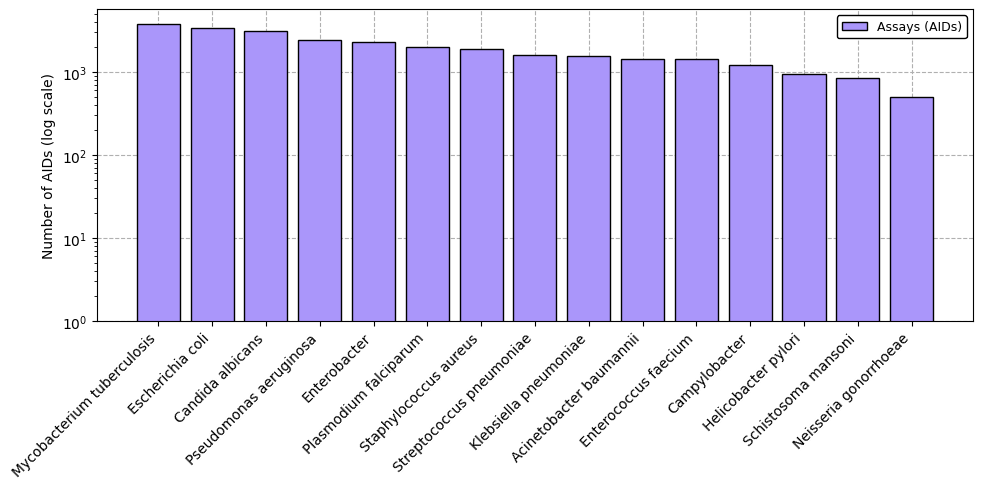

In [ ]:
x = np.arange(len(summary_by_pathogen))

values = summary_by_pathogen["N_AIDs"].values
labels = summary_by_pathogen["Pathogen"].values

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    x, values,
    color="#AA96FA",
    edgecolor="k",
    zorder=2,
    label="Assays (AIDs)"
)

plt.yscale("log")
plt.ylim(1, values.max() * 1.5)   # space above bars

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 4. Save Outputs

In [ ]:
# Save final csv file with all Taxonomy_ID and AID pairs
df_all.to_csv(DATA_PROCESSED / "all_taxid_aid.csv", index=False)

print("Saved: all_taxid_aid.csv")

Saved: all_taxid_aid.csv
